# 1. Load and convert to grayscale

In [19]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import filters

[[10  8  7 ... 10  9  5]
 [ 9  8  7 ...  6 10 10]
 [ 9  6  8 ... 10 14 12]
 ...
 [17 16 15 ...  9  6  9]
 [14 16 14 ... 11 11  6]
 [17 19 16 ... 14 15  9]]


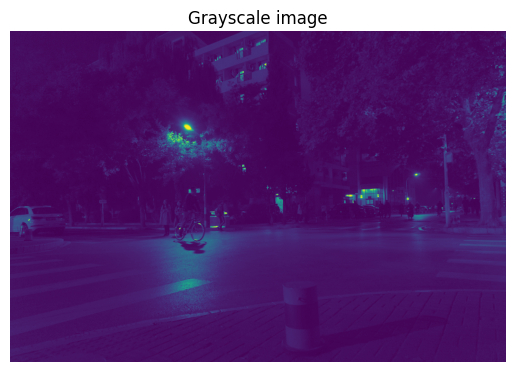

In [ ]:
def load(filename, folder = 'data/image/'):
    im=np.array(Image.open(folder+filename).convert('L'))
    return im

im1 = load('4050.png')
print(im1)
#Image.fromarray(im1).show() # Show a grayscale image when the code below have some green and blue
# Show the image 
plt.imshow(im1)
plt.title("Grayscale image")
plt.axis("off")

plt.show()

# 2. Histogram Equalization

Improve the global contrast of the picture.

In [32]:
def histeq(im,nbr_bins=256):
    """ Histogram equalization of a grayscale image. """
    # get image histogram
    imhist,bins = np.histogram(im.flatten(),nbr_bins)
    cdf = imhist.cumsum() # cumulative distribution function
    cdf = 255 * cdf / cdf[-1] # normalize
    # use linear interpolation of cdf to find new pixel values
    im2 = np.interp(im.flatten(),bins[:-1],cdf)
    return im2.reshape(im.shape), cdf

im2,cdf = histeq(im1, nbr_bins=500)
Image.fromarray(im2).show()
'''plt.imshow(im2, cmap='gray')
plt.title("Grayscale image")
plt.axis("off")

plt.show()'''

'plt.imshow(im2, cmap=\'gray\')\nplt.title("Grayscale image")\nplt.axis("off")\n\nplt.show()'

# 3. Use the convolution

Will reduce the noise on the picture.

In [28]:
def smooth(image):
    image_transformed = filters.gaussian_filter(image, sigma = 0.15)
    return image_transformed

C:\Users\emmar\AppData\Local\Temp\ipykernel_10516\238194451.py:2: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  image_transformed = filters.gaussian_filter(image, sigma = 0.15)


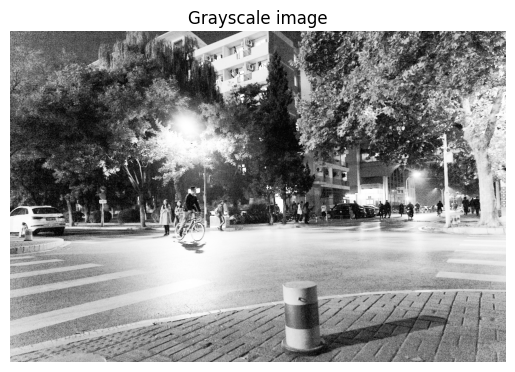

In [ ]:
im3 = smooth(im2)
Image.fromarray(im3).show()
'''plt.imshow(im3, cmap='gray')
plt.title("Grayscale image")
plt.axis("off")

plt.show()'''

# 4. Adaptative thresolding (maybe)